# Importing required libraries and setup

In [198]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

warnings.filterwarnings('ignore')


In [199]:
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

# Loading dataset 

In [200]:
data = pd.read_csv('loan_data.csv')

# EDA & Data cleaning 

In [201]:
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [202]:
data.shape

(45000, 14)

In [203]:
data.size

630000

In [204]:
data.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [205]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [206]:
data.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [207]:
data.duplicated().sum()

np.int64(0)

In [208]:
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [209]:
cat_cols =['person_gender', 'person_education',
        'person_home_ownership',  'loan_intent',
         'previous_loan_defaults_on_file']

In [210]:
for col in cat_cols :
    print(data[col].value_counts())
    print("=========================")

person_gender
male      24841
female    20159
Name: count, dtype: int64
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


In [211]:
for col in cat_cols:
    print(data.groupby(col)['loan_status'].value_counts())
    print("===================================")

person_gender  loan_status
female         0              15674
               1               4485
male           0              19326
               1               5515
Name: count, dtype: int64


person_education  loan_status
Associate         0               9378
                  1               2650
Bachelor          0              10381
                  1               3018
Doctorate         0                479
                  1                142
High School       0               9301
                  1               2671
Master            0               5461
                  1               1519
Name: count, dtype: int64
person_home_ownership  loan_status
MORTGAGE               0              16345
                       1               2144
OTHER                  0                 78
                       1                 39
OWN                    0               2729
                       1                222
RENT                   0              15848
                       1               7595
Name: count, dtype: int64
loan_intent        loan_status
DEBTCONSOLIDATION  0              4982
                   1              2163
EDUCATION          0            

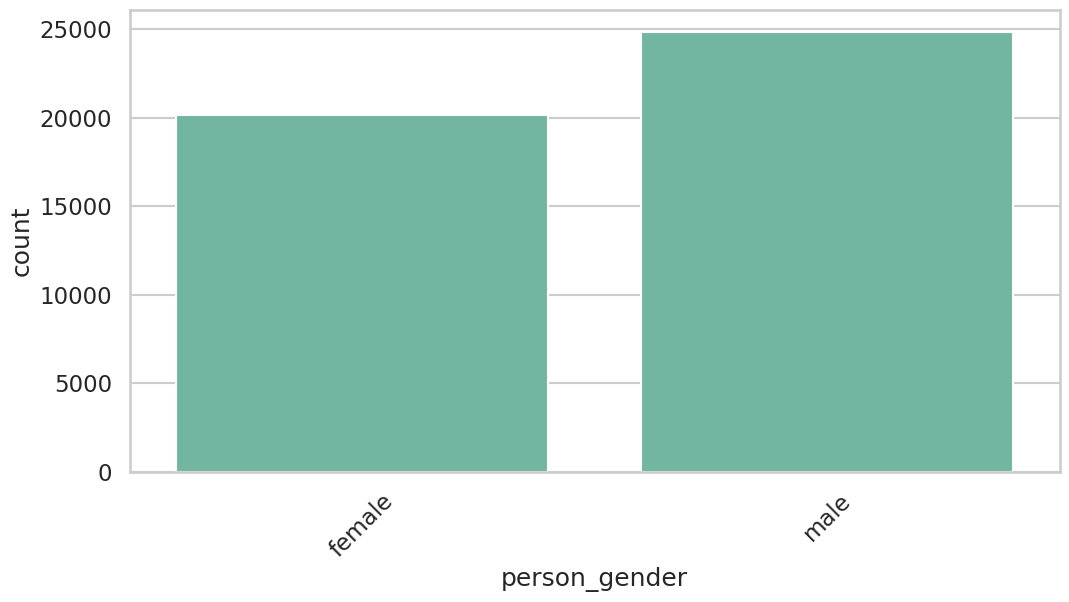

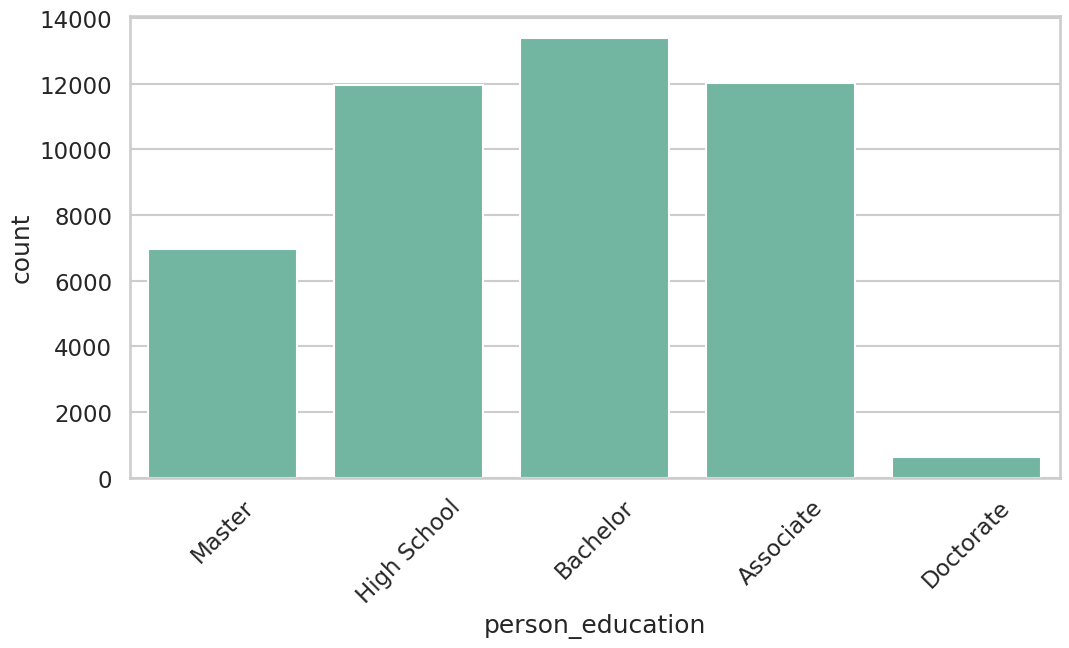

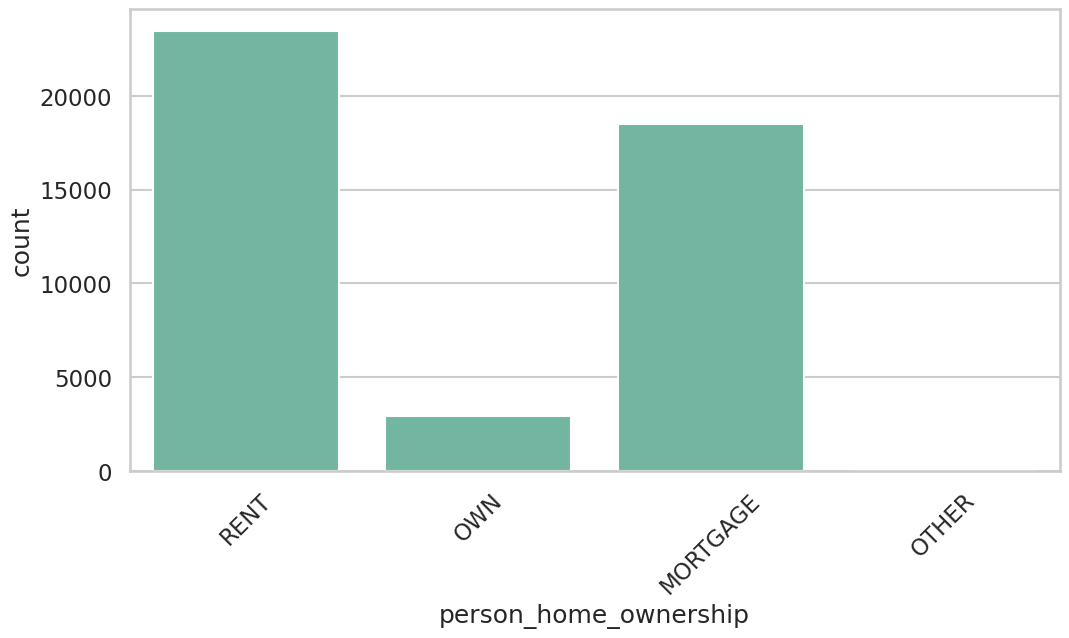

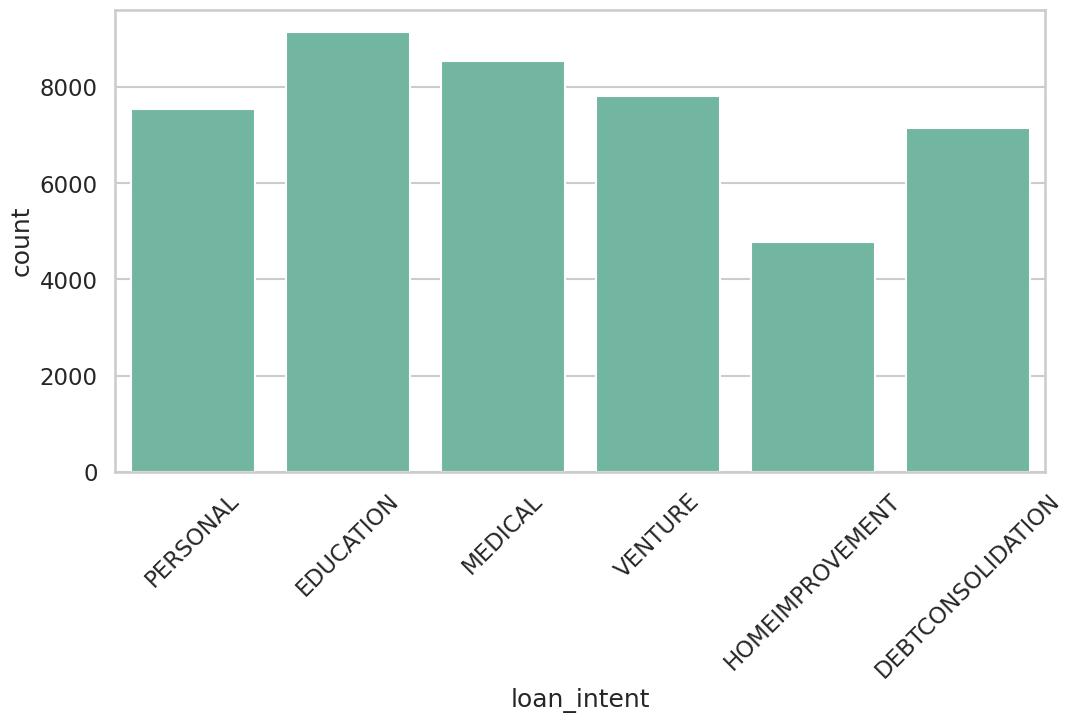

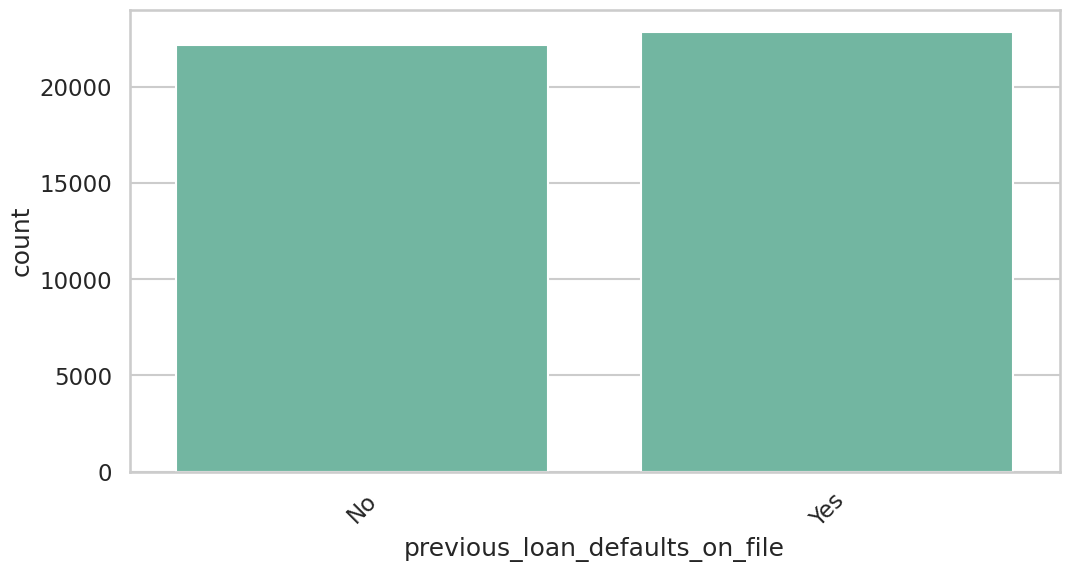

In [212]:
for col in cat_cols:
    plt.figure(figsize= (12,6))
    sns.countplot(x = data[col])
    plt.xticks(rotation= 45)
    plt.show()

In [213]:
num_cols = ['person_age',  'person_income',
       'person_emp_exp', 'loan_amnt', 
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']

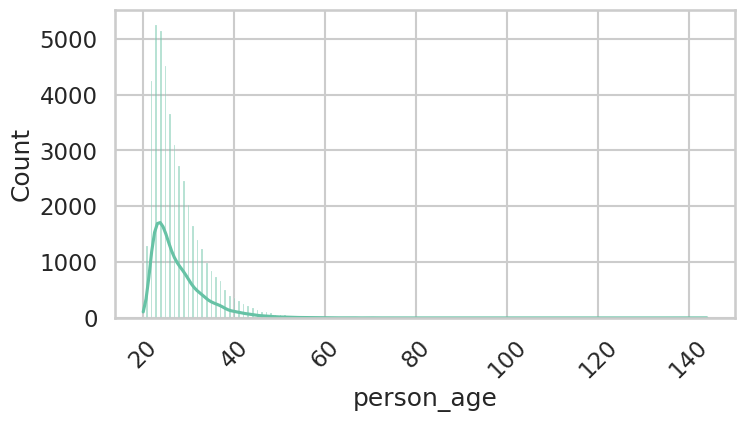

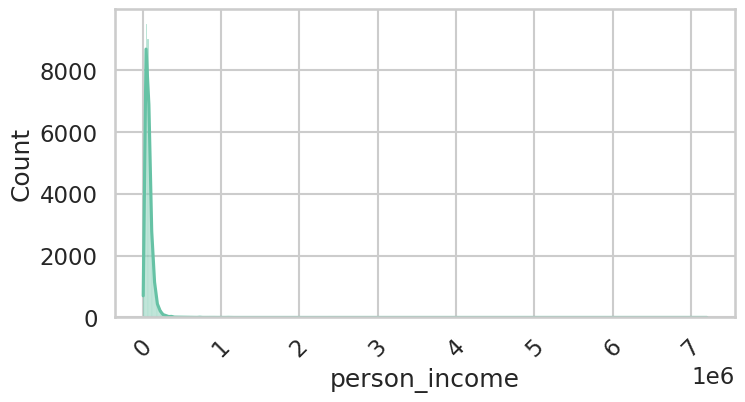

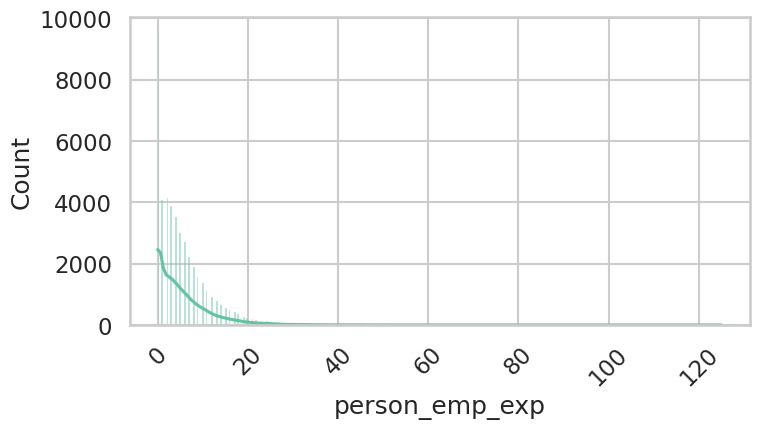

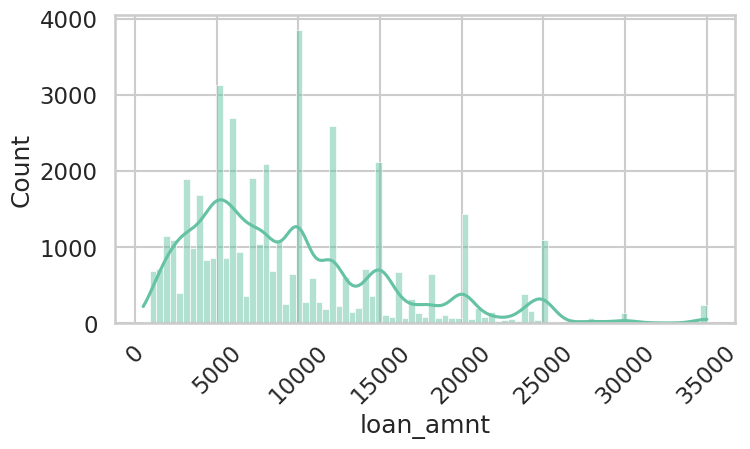

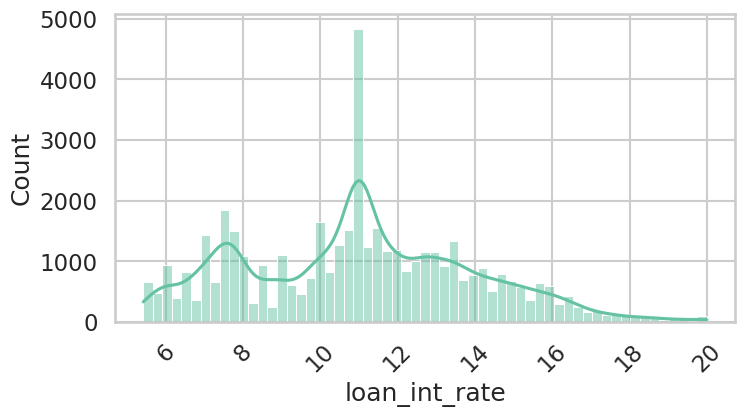

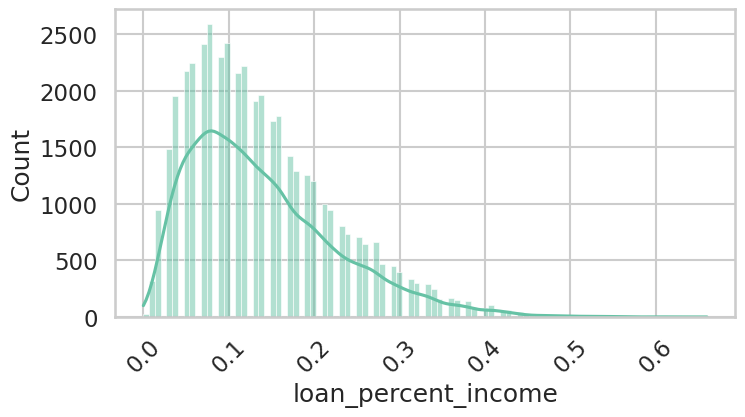

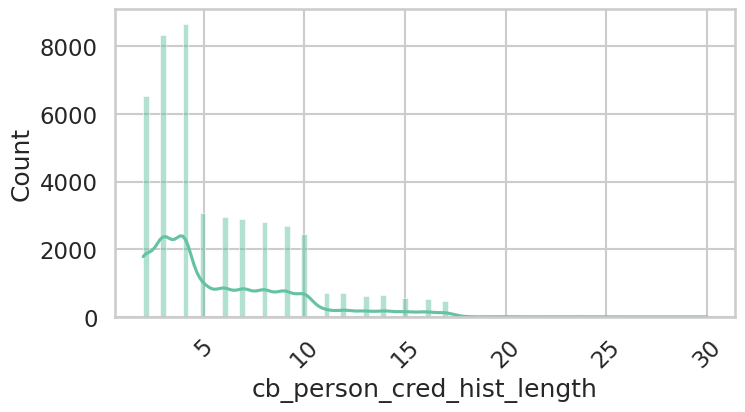

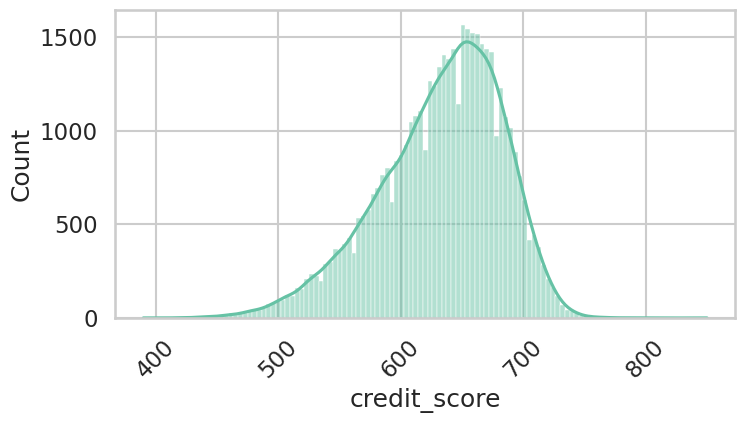

In [214]:
for col in num_cols:
    plt.figure(figsize= (8,4))
    sns.histplot(x = data[col], kde= True)
    plt.xticks(rotation= 45)
    plt.show()

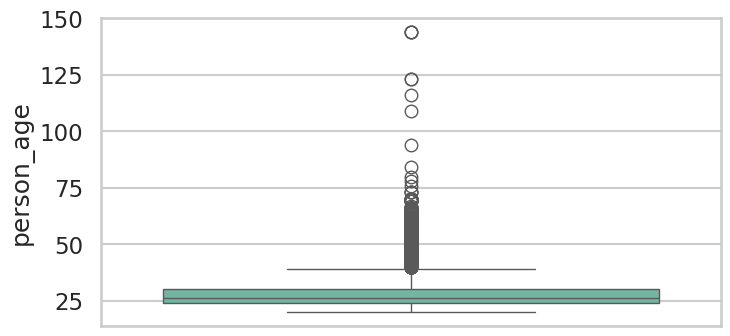

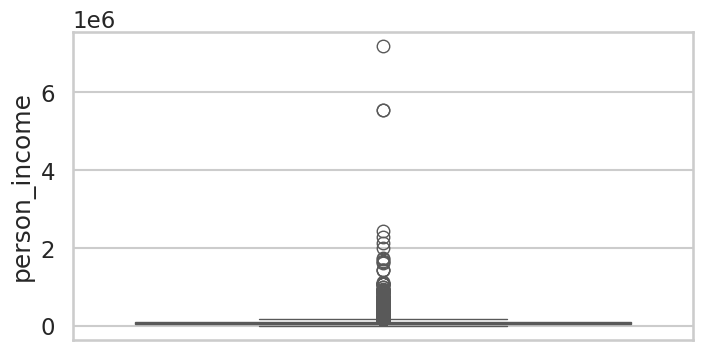

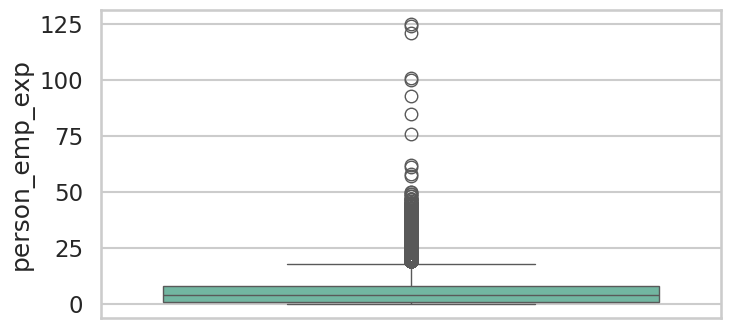

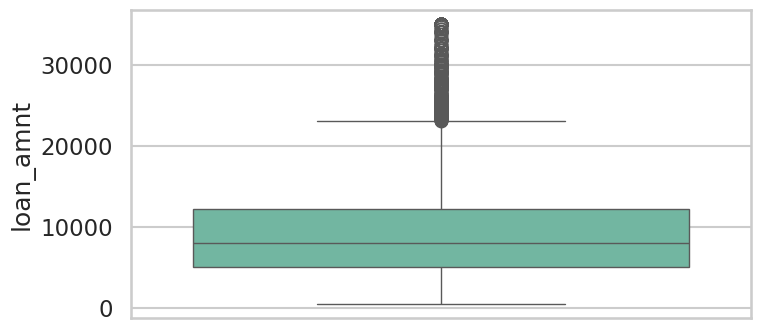

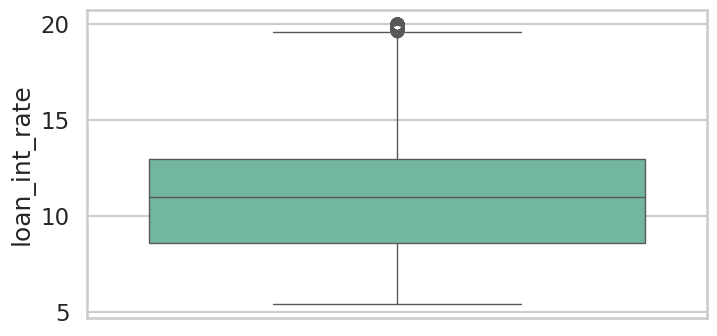

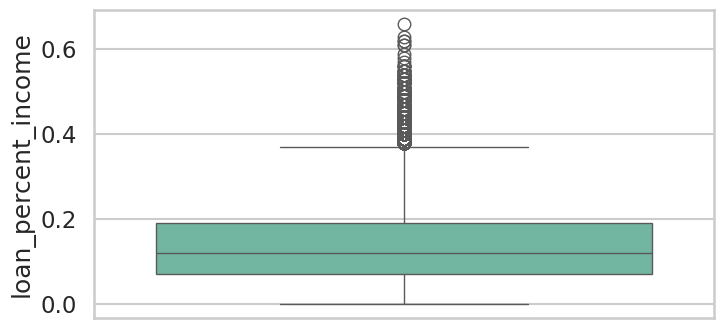

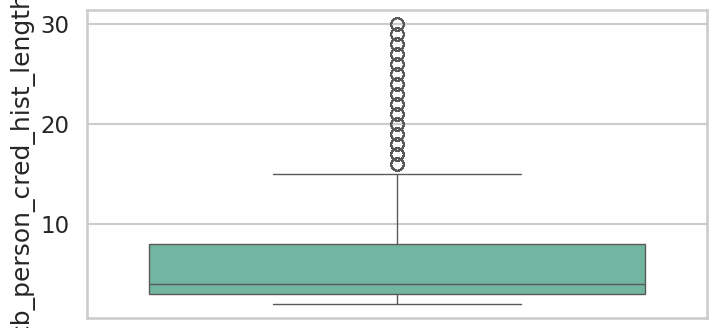

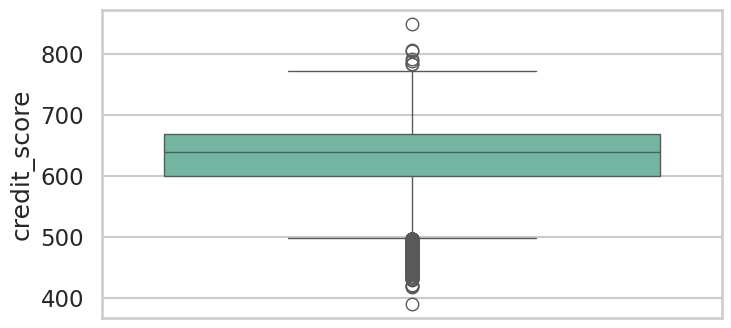

In [215]:
for col in num_cols:
    plt.figure(figsize= (8,4))
    sns.boxplot(y = data[col])
    plt.xticks(rotation= 45)
    plt.show()

# Removing unexpectable and logically wrong values 

In [216]:
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [217]:
data[data["person_age"] > 70]["person_age"].value_counts().sort_index()

person_age
73.0     3
76.0     1
78.0     1
80.0     1
84.0     1
94.0     1
109.0    1
116.0    1
123.0    2
144.0    3
Name: count, dtype: int64

In [218]:
data = data[data["person_age"] <= 80]

<Axes: ylabel='person_age'>

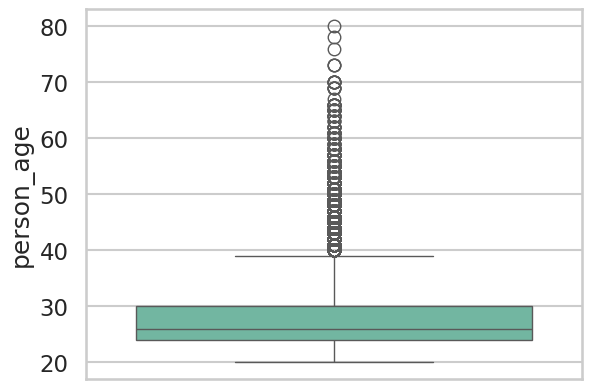

In [219]:
sns.boxplot(y = data['person_age'])

In [220]:
data[data['person_emp_exp'] > data['person_age'] - 15]['person_emp_exp'].value_counts().sort_index()

Series([], Name: count, dtype: int64)

<Axes: ylabel='person_emp_exp'>

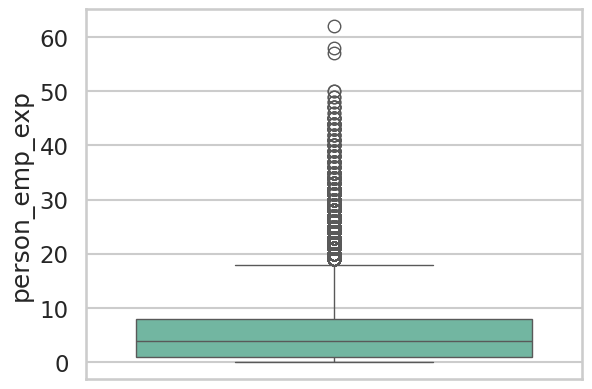

In [221]:
sns.boxplot(y = data['person_emp_exp'])

In [222]:
data.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44991.000000,4.499100e+04,44991.000000,44991.000000,44991.000000,44991.000000,44991.000000,44991.000000,44991.000000
mean,27.745705,7.990879e+04,5.391723,9583.236025,11.006526,0.139736,5.865684,632.579227,0.222267
std,5.895647,6.332289e+04,5.912127,6314.925978,2.979006,0.087208,3.875030,50.394127,0.415774
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719650e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577600e+04,8.000000,12237.500000,12.990000,0.190000,8.000000,670.000000,0.000000
max,80.000000,2.448661e+06,62.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


**Saving person income as log value**

In [223]:
data["person_income"] = np.log1p(data["person_income"])

In [224]:
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,11.183713,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,9.415971,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,9.428592,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,11.286702,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,11.099469,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


<Axes: ylabel='person_income'>

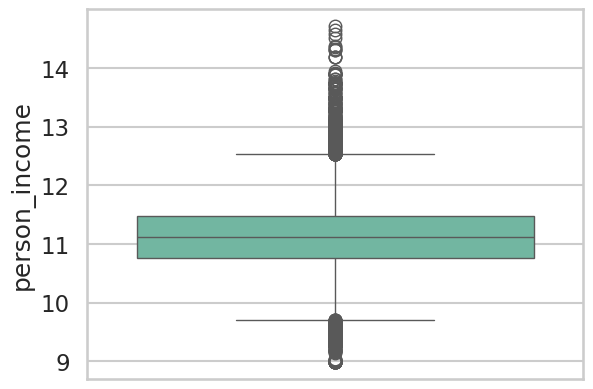

In [225]:
sns.boxplot(y = data['person_income'])

<Axes: >

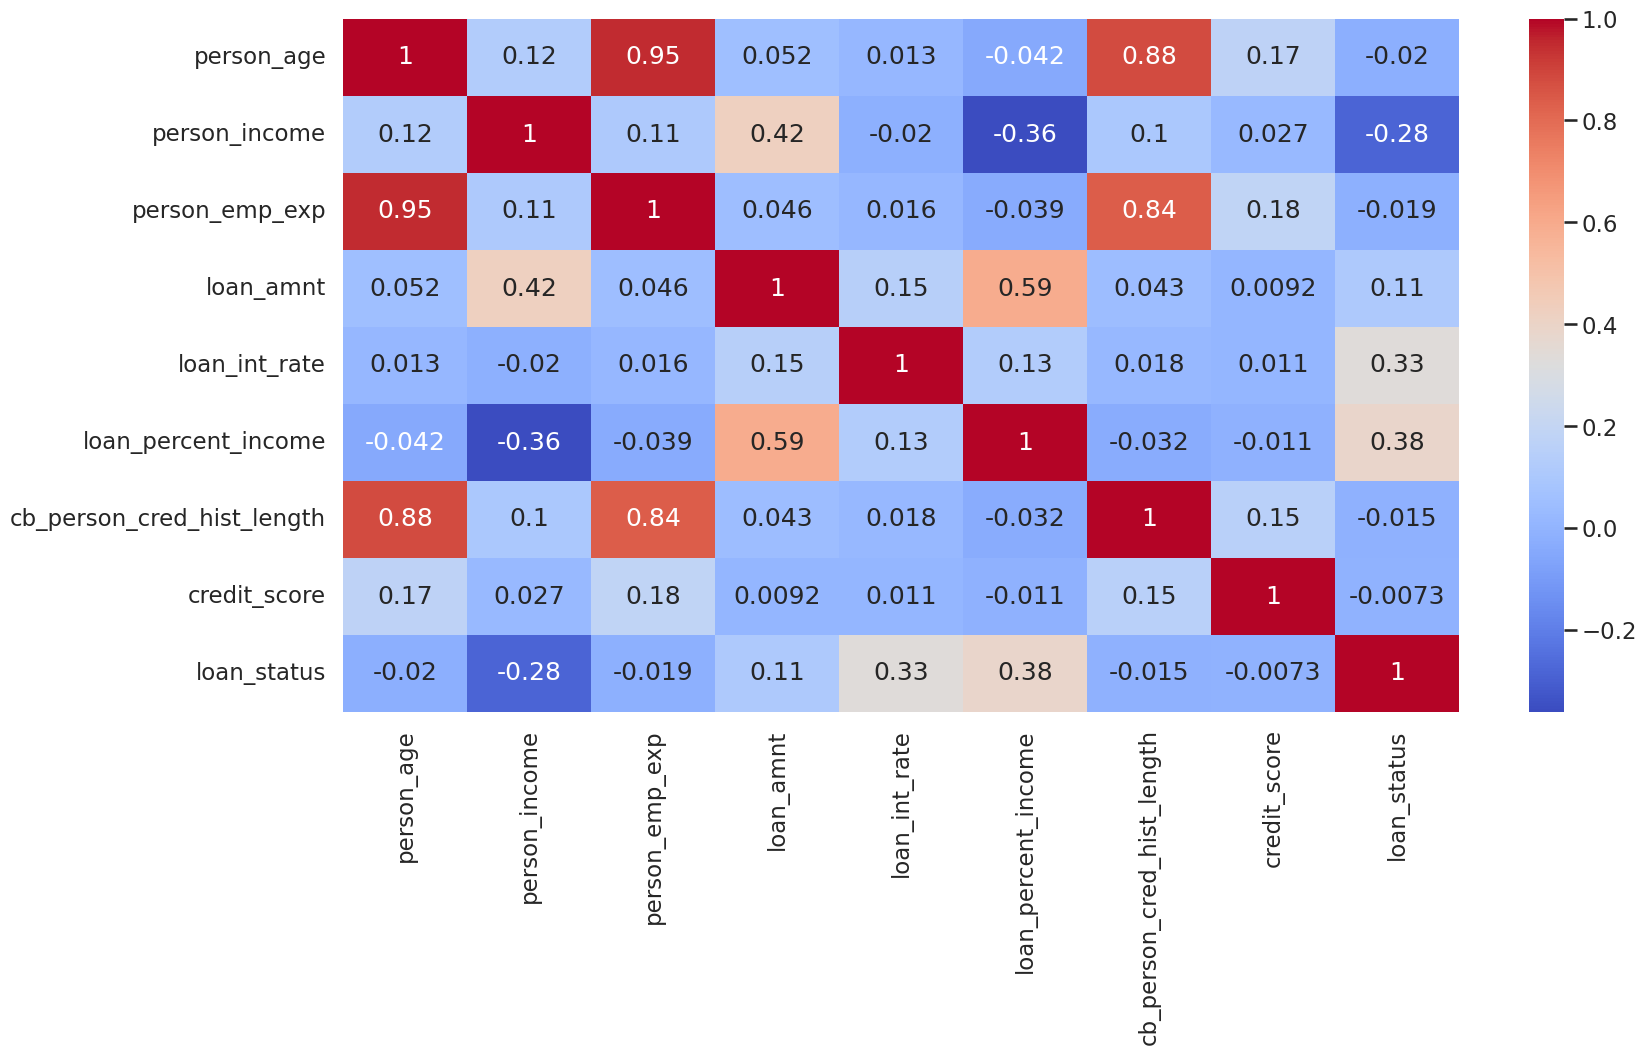

In [226]:
plt.figure(figsize= (18,9))

sns.heatmap(data.corr(numeric_only=True), annot= True, cmap= 'coolwarm')

# Label encoding 

In [227]:
data.info()

<class 'pandas.DataFrame'>
Index: 44991 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44991 non-null  float64
 1   person_gender                   44991 non-null  str    
 2   person_education                44991 non-null  str    
 3   person_income                   44991 non-null  float64
 4   person_emp_exp                  44991 non-null  int64  
 5   person_home_ownership           44991 non-null  str    
 6   loan_amnt                       44991 non-null  float64
 7   loan_intent                     44991 non-null  str    
 8   loan_int_rate                   44991 non-null  float64
 9   loan_percent_income             44991 non-null  float64
 10  cb_person_cred_hist_length      44991 non-null  float64
 11  credit_score                    44991 non-null  int64  
 12  previous_loan_defaults_on_file  44991 non-null  

In [228]:
data['person_gender'].value_counts()

person_gender
male      24834
female    20157
Name: count, dtype: int64

In [229]:
data['previous_loan_defaults_on_file'].value_counts()

previous_loan_defaults_on_file
Yes    22855
No     22136
Name: count, dtype: int64

In [230]:
data['person_gender'] = data['person_gender'].map({'male': 1, 'female': 0})

data.rename(columns={'person_gender': 'is_male',
                     'previous_loan_defaults_on_file' : 'has_previous_defaults'}, inplace=True)

data['has_previous_defaults'] = data['has_previous_defaults'].map({'Yes': 1, 'No': 0})

In [231]:
data.info()

<class 'pandas.DataFrame'>
Index: 44991 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  44991 non-null  float64
 1   is_male                     44991 non-null  int64  
 2   person_education            44991 non-null  str    
 3   person_income               44991 non-null  float64
 4   person_emp_exp              44991 non-null  int64  
 5   person_home_ownership       44991 non-null  str    
 6   loan_amnt                   44991 non-null  float64
 7   loan_intent                 44991 non-null  str    
 8   loan_int_rate               44991 non-null  float64
 9   loan_percent_income         44991 non-null  float64
 10  cb_person_cred_hist_length  44991 non-null  float64
 11  credit_score                44991 non-null  int64  
 12  has_previous_defaults       44991 non-null  int64  
 13  loan_status                 44991 non-null  int

In [232]:
data = pd.get_dummies(data, columns=['person_education', 'person_home_ownership', 'loan_intent'], dtype=int)

In [233]:
data.head()

,person_age,is_male,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,has_previous_defaults,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,11.183713,0,35000.0,16.02,0.49,3.0,561,0,...,0,0,0,1,0,0,0,0,1,0
1,21.0,0,9.415971,0,1000.0,11.14,0.08,2.0,504,1,...,0,0,1,0,0,1,0,0,0,0
2,25.0,0,9.428592,3,5500.0,12.87,0.44,3.0,635,0,...,1,0,0,0,0,0,0,1,0,0
3,23.0,0,11.286702,0,35000.0,15.23,0.44,2.0,675,0,...,0,0,0,1,0,0,0,1,0,0
4,24.0,1,11.099469,1,35000.0,14.27,0.53,4.0,586,0,...,0,0,0,1,0,0,0,1,0,0


In [234]:
data.columns

Index(['person_age', 'is_male', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'has_previous_defaults', 'loan_status',
       'person_education_Associate', 'person_education_Bachelor',
       'person_education_Doctorate', 'person_education_High School',
       'person_education_Master', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE'],
      dtype='str')

In [235]:
data.head()

,person_age,is_male,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,has_previous_defaults,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,11.183713,0,35000.0,16.02,0.49,3.0,561,0,...,0,0,0,1,0,0,0,0,1,0
1,21.0,0,9.415971,0,1000.0,11.14,0.08,2.0,504,1,...,0,0,1,0,0,1,0,0,0,0
2,25.0,0,9.428592,3,5500.0,12.87,0.44,3.0,635,0,...,1,0,0,0,0,0,0,1,0,0
3,23.0,0,11.286702,0,35000.0,15.23,0.44,2.0,675,0,...,0,0,0,1,0,0,0,1,0,0
4,24.0,1,11.099469,1,35000.0,14.27,0.53,4.0,586,0,...,0,0,0,1,0,0,0,1,0,0


# Hypothesis testing for Feature Selction 

**Anova test for numeric features**

In [236]:
from sklearn.feature_selection import SelectKBest, f_classif

numerical_features = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]

X_num = data[numerical_features]
y = data["loan_status"]

anova = SelectKBest(score_func=f_classif, k="all")
anova.fit(X_num, y)

anova_scores = pd.DataFrame({
    "Feature": numerical_features,
    "ANOVA Score": anova.scores_,
    "P-Value": anova.pvalues_
})

anova_scores["Decision"] = np.where(
    anova_scores["P-Value"] < 0.05,
    "✅ Keep",
    "❌ Remove"
)

anova_scores.sort_values("ANOVA Score", ascending=False)

,Feature,ANOVA Score,P-Value,Decision
5,loan_percent_income,7823.429821,0.000000e+00,✅ Keep
4,loan_int_rate,5574.662106,0.000000e+00,✅ Keep
1,person_income,3940.483851,0.000000e+00,✅ Keep
3,loan_amnt,528.172857,3.303727e-116,✅ Keep
0,person_age,18.635476,1.585860e-05,✅ Keep
2,person_emp_exp,16.808776,4.141419e-05,✅ Keep
6,cb_person_cred_hist_length,9.620221,1.925655e-03,✅ Keep
7,credit_score,2.424763,1.194384e-01,❌ Remove


**Chi-squared test**

In [237]:
cat_features = [
    'is_male',
    'has_previous_defaults',
    'person_education_Associate',
    'person_education_Bachelor',
    'person_education_Doctorate',
    'person_education_High School',
    'person_education_Master',
    'person_home_ownership_MORTGAGE',
    'person_home_ownership_OTHER',
    'person_home_ownership_OWN',
    'person_home_ownership_RENT',
    'loan_intent_DEBTCONSOLIDATION',
    'loan_intent_EDUCATION',
    'loan_intent_HOMEIMPROVEMENT',
    'loan_intent_MEDICAL',
    'loan_intent_PERSONAL',
    'loan_intent_VENTURE'
]

In [238]:
from scipy.stats import chi2_contingency

alpha = 0.05
chi2results = {}

for col in cat_features:
    contingency_table = pd.crosstab(data[col], data['loan_status'])
    
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    
    decision = "✅ Keep"if p_val <= alpha else "❌ Remove"
    
    chi2results[col] = {
        'chi2_stat' : chi2_stat,
        'p_value' : p_val ,
        'Decision' : decision
    }
    
    
chi2results_df = pd.DataFrame(chi2results).T
chi2results_df.sort_values(by='p_value', ascending=True)

,chi2_stat,p_value,Decision
has_previous_defaults,13272.901595,0.0,✅ Keep
person_home_ownership_RENT,2930.182819,0.0,✅ Keep
person_home_ownership_MORTGAGE,2048.767689,0.0,✅ Keep
person_home_ownership_OWN,394.080039,0.0,✅ Keep
loan_intent_VENTURE,331.71888,0.0,✅ Keep
loan_intent_DEBTCONSOLIDATION,317.566139,0.0,✅ Keep
loan_intent_MEDICAL,190.743171,0.0,✅ Keep
loan_intent_EDUCATION,183.953768,0.0,✅ Keep
loan_intent_HOMEIMPROVEMENT,51.143861,0.0,✅ Keep
loan_intent_PERSONAL,22.583125,0.000002,✅ Keep


**Mutual information test**

In [239]:
from sklearn.feature_selection import mutual_info_classif


X = data.drop("loan_status", axis=1)
y = data["loan_status"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})

mi_df["Decision"] = np.where(
    mi_df["MI Score"] > 0,
    "✅ Keep",
    "❌ Remove"
)

mi_df.sort_values("MI Score", ascending=False)

,Feature,MI Score,Decision
9,has_previous_defaults,0.195705,✅ Keep
2,person_income,0.091474,✅ Keep
6,loan_percent_income,0.083853,✅ Keep
5,loan_int_rate,0.072321,✅ Keep
18,person_home_ownership_RENT,0.039109,✅ Keep
15,person_home_ownership_MORTGAGE,0.028927,✅ Keep
4,loan_amnt,0.015089,✅ Keep
19,loan_intent_DEBTCONSOLIDATION,0.006824,✅ Keep
17,person_home_ownership_OWN,0.006386,✅ Keep
1,is_male,0.005758,✅ Keep


# Final DataFrame for 1st Model

**Since there are only 26 features in DataFrame and not very strong decision is present to remove any feature me decide it after making the first model and checking its accuracy**

In [240]:
selected_features = [
    'person_age',
    'is_male',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score',
    'has_previous_defaults',

    'person_education_Associate',
    'person_education_Bachelor',
    'person_education_Doctorate',
    'person_education_High School',
    'person_education_Master',

    'person_home_ownership_MORTGAGE',
    'person_home_ownership_OTHER',
    'person_home_ownership_OWN',
    'person_home_ownership_RENT',

    'loan_intent_DEBTCONSOLIDATION',
    'loan_intent_EDUCATION',
    'loan_intent_HOMEIMPROVEMENT',
    'loan_intent_MEDICAL',
    'loan_intent_PERSONAL',
    'loan_intent_VENTURE',
    
    
]

data_first = data[selected_features]

# Test train splitting & standardization

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[selected_features]
y = data["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [242]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((35992, 25), (8999, 25), (35992,), (8999,))